<a href="https://colab.research.google.com/github/Xyrfo/Pembelajaran-Mesin/blob/main/JS05/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 - Klasifikasi Naive Bayes dengan Data Dummy

Membandingkan `MultinomialNB` untuk fitur diskrit dan `GaussianNB` untuk fitur kontinu.

In [10]:
import numpy as np
from sklearn.datasets import make_classification

## Langkah 1 - Membuat Dataset Dummy

In [11]:
X, y = make_classification(
    n_samples=30, n_features=2, n_classes=2,
    n_informative=2, n_redundant=0, n_repeated=0,
    shuffle=False, random_state=42
)

# MultinomialNB memerlukan fitur non-negatif dan umumnya digunakan pada data diskrit.
X = np.round(np.absolute(X), 2) * 100
X = X.astype(int)
print(X)
print(y)

[[112 139]
 [179 210]
 [ 83  71]
 [182 265]
 [105  78]
 [ 67  43]
 [ 36  54]
 [ 20  70]
 [122  70]
 [250  83]
 [ 50 142]
 [206 110]
 [115  84]
 [124  66]
 [150  85]
 [ 16  73]
 [ 46 113]
 [ 26  80]
 [ 18 114]
 [211 154]
 [ 53  66]
 [ 93 109]
 [175 172]
 [ 80  85]
 [111 125]
 [115 105]
 [ 66  92]
 [160  85]
 [ 53 106]
 [122  85]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


# Langkah 2 (Opsional) - Membuat Data Frame

In [12]:
import pandas as pd

# Reshape label y menjadi 2D
# Hal ini dilakukan karena kita akan menggabungkannya dengan data fitur X
y_new = y.reshape(len(y), 1)

# Gabungkan fitur X dan label y dalam data array
data = np.concatenate((X, y_new), axis=1)

# Definisikan nama kolom
nama_kolom = ['Fitur 1', 'Fitur 2', 'Label']

# Buat Data Frame
df = pd.DataFrame(data, columns=nama_kolom)

# Cek Data Frame
df.head()

,Fitur 1,Fitur 2,Label
0,112,139,0
1,179,210,0
2,83,71,0
3,182,265,0
4,105,78,0


# Langkah 3 (Opsional) - Labeling

In [13]:
	# Definisikan nama label
	labels = {
	    1 : 'Kelas A',
	    0 : 'Kelas B'
	}

	# Copy Data Frame untuk menyimpan Data Frame baru
	# dengan label yang mudah untuk dibaca
	df_label = df.copy()

	# Ubah label dengan fungsi mapping dari Pandas
	# pada Data Frame df_label
	df_label['Label'] = df_label['Label'].map(labels)

	# Cek Data Frame df_label
	df_label.head()

,Fitur 1,Fitur 2,Label
0,112,139,Kelas B
1,179,210,Kelas B
2,83,71,Kelas B
3,182,265,Kelas B
4,105,78,Kelas B


## Langkah 4 - Visualisasi Data

/tmp/ipykernel_1299/1912510248.py:11: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Kelas A')
/tmp/ipykernel_1299/1912510248.py:12: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Kelas B')


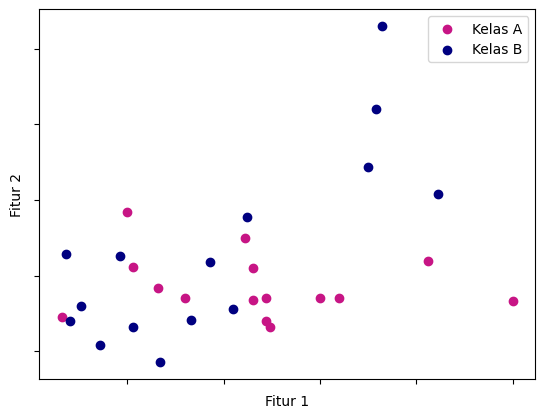

In [14]:
	import matplotlib.pyplot as plt

	# Definisikan warna untuk setiap kelas
	colors = {
	    'class_a': 'MediumVioletRed',
	    'class_b': 'Navy'
	}

	# Kelompokkan label berdasarkan nama kelas
	gb = df_label.groupby(['Label'])
	class_a = gb.get_group('Kelas A')
	class_b = gb.get_group('Kelas B')

	# Plot
	plt.scatter(x=class_a['Fitur 1'], y=class_a['Fitur 2'], c=colors['class_a'])
	plt.scatter(x=class_b['Fitur 1'], y=class_b['Fitur 2'], c=colors['class_b'])
	plt.xlabel('Fitur 1')
	plt.ylabel('Fitur 2')
	plt.legend(['Kelas A', 'Kelas B'])
	plt.gca().axes.xaxis.set_ticklabels([])
	plt.gca().axes.yaxis.set_ticklabels([])
	plt.show()

#Langkah 5 - Model Multinomial Naive Bayes

In [15]:
	from sklearn.naive_bayes import MultinomialNB # class untuk model MultinomialNB
	from sklearn.model_selection import train_test_split
	from sklearn.metrics import accuracy_score # evaluasi model berdasarkan akurasi

	# Inisiasi obyek MultinomialNB
	mnb = MultinomialNB()

	# Kita dapat langsung menggunakan fitur X dan label y
	# hasil dari proses pembuatan data dummy

	# Split data training dan testing
	X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)

	# Fit model
	# Label y harus dalam bentuk 1D atau (n_samples,)
	mnb.fit(X_train, y_train)

	# Prediksi dengan data training
	y_train_pred = mnb.predict(X_train)

	# Evaluasi akurasi training
	acc_train = accuracy_score(y_train, y_train_pred)

	# Prediksi test data
	y_test_pred = mnb.predict(X_test)

	# Evaluasi model dengan metric akurasi
	acc_test = accuracy_score(y_test, y_test_pred)

	# Print hasil evaluasi
	print(f'Hasil akurasi data train: {acc_train}')
	print(f'Hasil akurasi data test: {acc_test}')

Hasil akurasi data train: 0.8095238095238095
Hasil akurasi data test: 0.3333333333333333


# Langkah 6 - Model Gaussian Naive Bayes

In [16]:
	from sklearn.naive_bayes import GaussianNB # class untuk model GaussianNB

	# Inisiasi obyek Gaussian
	gnb = GaussianNB()

	# Kita menggunakan split data training dan testing
	# yang sama dengan model multinomial

	# Fit model
	# Label y harus dalam bentu 1D atau (n_samples,)
	gnb.fit(X_train, y_train)

	# Prediksi dengan data training
	y_train_pred_gnb = gnb.predict(X_train)

	# Evaluasi akurasi training
	acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

	# Prediksi test data
	y_test_pred_gnb = gnb.predict(X_test)

	# Evaluasi model dengan metric akurasi
	acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

	# Print hasil evaluasi
	print(f'Hasil akurasi data train (Gaussian): {acc_train_gnb}')
	print(f'Hasil akurasi data test (Gaussian): {acc_test_gnb}')

Hasil akurasi data train (Gaussian): 0.8571428571428571
Hasil akurasi data test (Gaussian): 0.4444444444444444
